# TP ML & TM: SVM

**Activité 1: SVM Linéaire**

Considérons les programmes suivants:

In [35]:
import pandas as pd
from numpy import *
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.svm import LinearSVC, SVC

1.0
[-0.813044700590385, 0.44138318807984256, -0.5161653078436885]


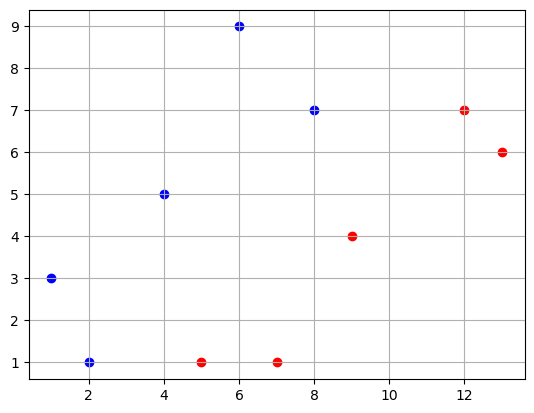

In [36]:
data = pd.read_csv("data/pointsSVM.csv", sep=';')
data = array(data)
x = data[:,0:2]
y = data[:,2]
axes = plt.axes()
axes.grid()
plt.scatter(x[y ==+1][:,0], x[y==+1][:,1], color='r')
plt.scatter(x[y ==-1][:,0], x[y==-1][:,1], color='b')
def f(X,Beta):
    return Beta[0]+sum(X*Beta[1:])
def classer(X,Beta):
    return int(sign(f(X,Beta)))
lsvm = LinearSVC(C=1)
X_train = data[:,0:2]
y_train = data[:,2]
lsvm.fit(X_train, y_train)
score = lsvm.score(X_train, y_train)
print(score)
Beta=list(lsvm.intercept_) + list(lsvm.coef_[0])
print(Beta)
plt.show()


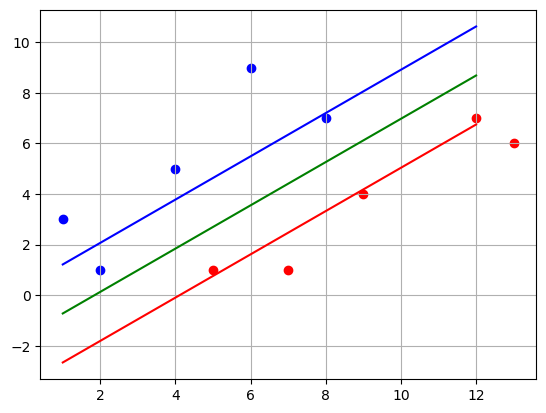

[-0.813044700590385, 0.44138318807984256, -0.5161653078436885]
[5,1]==> 0.8777059319651391
[2,1] -0.44644363227438844
[6,9]==> -2.810233342704526
[12,2] 3.967388248524038


In [37]:
axes = plt.axes()
axes.grid()
plt.scatter(x[y==+1][:,0], x[y==+1][:,1], color='r')
plt.scatter(x[y==-1][:,0], x[y==-1][:,1], color='b')
Bleu=[]; Rouge=[]; milieu=[]
for abscisseX in range(1,13):
    y=-1.0*(Beta[0]+Beta[1]*abscisseX+1)/Beta[2];  Bleu+=[y]
    y=-1.0*(Beta[0]+Beta[1]*abscisseX-1)/Beta[2];  Rouge+=[y]
    y=-1.0*(Beta[0]+Beta[1]*abscisseX)/Beta[2];  milieu+=[y]
plt.plot(arange(1,13),Bleu,color='b')
plt.plot(arange(1,13),Rouge,color='r')
plt.plot(arange(1,13),milieu,color='g')
plt.show()
print(Beta)
print('[5,1]==>',f(array([5,1]),Beta));print('[2,1]',f(array([2,1]),Beta))
print('[6,9]==>',f(array([6,9]),Beta));print('[12,2]',f(array([12,1]),Beta))

**Activité 2: SVM non Linéaire**

1.0
1.0
0.7
[-0.03321889276213615, 0.10400431898585807, -0.1508200871587443]


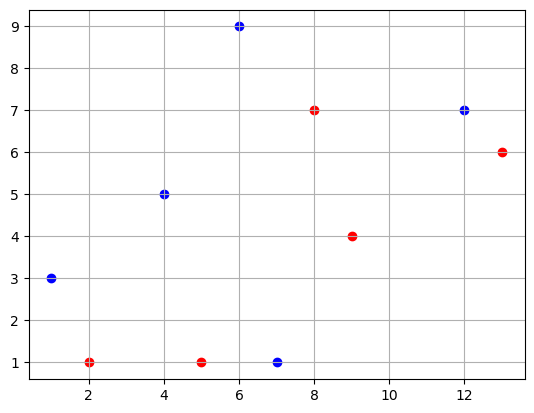

In [38]:
donnees= pd.read_csv("data/pointsSVM2.csv",sep=';')
donnees=array(donnees); x=donnees[:,0:2]; y=donnees[:,2];
axes = plt.axes(); axes.grid()
plt.scatter(x[y ==+1][:, 0], x[y ==+1][:, 1], color='r')
plt.scatter(x[y ==-1][:, 0], x[y == -1][:, 1], color='b')
def f(X,Beta):    return Beta[0]+sum(X.T*Beta[1:])
def classer(X,Beta):    return int(sign(f(X,Beta)))
from sklearn.svm import LinearSVC, SVC,NuSVC
X_tr=donnees[:,0:2]; y_tr=donnees[:,2]
lsvm= SVC(gamma='auto');lsvm.fit(X_tr, y_tr);
score = lsvm.score(X_tr, y_tr); print(score);
lsvm= NuSVC(gamma='auto');lsvm.fit(X_tr, y_tr);
score = lsvm.score(X_tr, y_tr); print(score);
lsvm= LinearSVC(C=1000);lsvm.fit(X_tr, y_tr);
score = lsvm.score(X_tr, y_tr); print(score);
Beta=list(lsvm.intercept_)+list(lsvm.coef_[0]); print(Beta)
plt.show()